In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import PyTorchModelHubMixin

print("Torch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.13.0+cpu
Using device: cpu


In [2]:
class Generator(nn.Module, PyTorchModelHubMixin):
    """DCGAN generator: latent vector -> 64x64 image."""

    def __init__(self, num_channels=3, latent_dim=100, hidden_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            # input: (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, hidden_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(hidden_size * 8),
            nn.ReLU(True),
            # (hidden_size*8) x 4 x 4
            nn.ConvTranspose2d(hidden_size * 8, hidden_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size * 4),
            nn.ReLU(True),
            # (hidden_size*4) x 8 x 8
            nn.ConvTranspose2d(hidden_size * 4, hidden_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size * 2),
            nn.ReLU(True),
            # (hidden_size*2) x 16 x 16
            nn.ConvTranspose2d(hidden_size * 2, hidden_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(True),
            # (hidden_size) x 32 x 32
            nn.ConvTranspose2d(hidden_size, num_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
            # (num_channels) x 64 x 64  -- Tanh output lives in [-1, 1]
        )

    def forward(self, noise):
        return self.model(noise)

In [3]:
MODEL_ID = "huggan/dcgan-mnist"

try:
    generator = Generator.from_pretrained(MODEL_ID)
    print(f"Loaded pretrained weights from '{MODEL_ID}'.")
except Exception as e:
    # Falls back to an untrained generator so the rest of the notebook still runs
    # (useful if you're offline or a firewall blocks the Hub). Output will look
    # like colored static instead of digits until real weights are loaded.
    print(f"Could not download '{MODEL_ID}' ({e}).\nFalling back to a randomly initialized generator.")
    generator = Generator(num_channels=1, latent_dim=100, hidden_size=64)

generator = generator.to(device)
generator.eval()  # inference mode: disables dropout, freezes BatchNorm running stats

LATENT_DIM = generator.latent_dim
print("Latent (noise) vector size:", LATENT_DIM)

pytorch_model.bin:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Loaded pretrained weights from 'huggan/dcgan-mnist'.
Latent (noise) vector size: 100


C:\Users\Hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--huggan--dcgan-mnist. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [4]:
def make_noise(batch_size, latent_dim=LATENT_DIM, seed=None):
    """Sample a batch of random latent vectors z ~ N(0, 1)."""
    generator_state = torch.Generator(device=device)
    if seed is not None:
        generator_state.manual_seed(seed)
    return torch.randn(batch_size, latent_dim, 1, 1, device=device, generator=generator_state)

sample_noise = make_noise(batch_size=4, seed=0)
print(sample_noise.shape)

torch.Size([4, 100, 1, 1])


In [5]:
@torch.no_grad()
def generate_images(z):
    """Run z through the generator and convert Tanh output ([-1,1]) to displayable images in [0,1]."""
    fake = generator(z)                 # (batch, C, 64, 64), values in [-1, 1]
    fake = (fake + 1) / 2               # rescale to [0, 1] for plotting
    fake = fake.clamp(0, 1)
    fake = fake.cpu().permute(0, 2, 3, 1).numpy()   # -> (batch, H, W, C)
    return fake

images = generate_images(sample_noise)
print("images array shape:", images.shape)

images array shape: (4, 64, 64, 3)


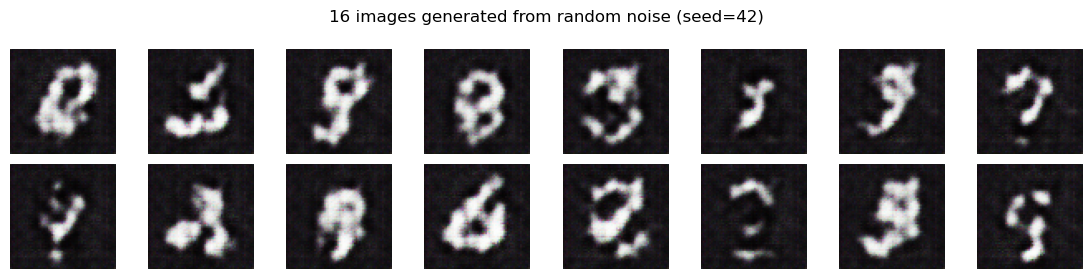

In [6]:
def show_images(images, ncols=8, title=None, figsize_scale=1.4):
    """Display a batch of images (shape N,H,W,C) in a grid with Matplotlib."""
    n = images.shape[0]
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_scale, nrows * figsize_scale))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            if img.shape[-1] == 1:   # grayscale
                ax.imshow(img.squeeze(-1), cmap="gray")
            else:
                ax.imshow(img)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Generate a bigger batch of images from fresh random noise and display them
z = make_noise(batch_size=16, seed=42)
images = generate_images(z)
show_images(images, ncols=8, title="16 images generated from random noise (seed=42)")

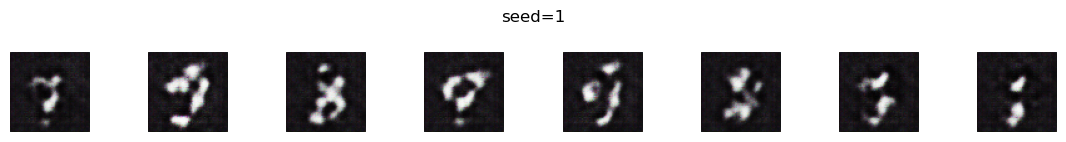

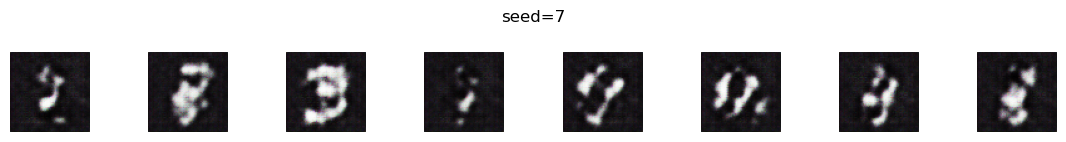

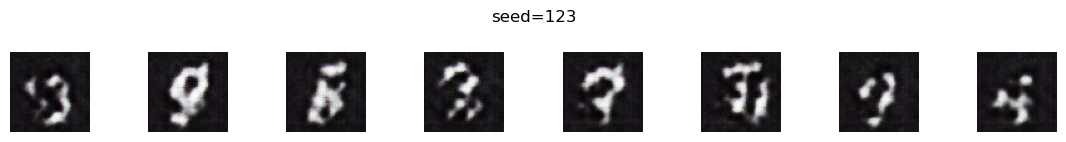

In [7]:
# 1. Different seeds -> different generated batches
for seed in [1, 7, 123]:
    z = make_noise(batch_size=8, seed=seed)
    imgs = generate_images(z)
    show_images(imgs, ncols=8, title=f"seed={seed}")

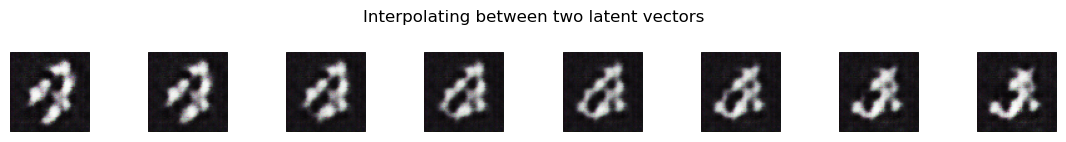

In [8]:
# 2. Latent-space interpolation between two random vectors
@torch.no_grad()
def interpolate(z_start, z_end, steps=8):
    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1, 1, 1)
    return z_start.unsqueeze(0) * (1 - alphas) + z_end.unsqueeze(0) * alphas

z1 = make_noise(batch_size=1, seed=10)[0]
z2 = make_noise(batch_size=1, seed=20)[0]
z_path = interpolate(z1, z2, steps=8).squeeze(1)   # (steps, latent_dim, 1, 1)

imgs = generate_images(z_path)
show_images(imgs, ncols=8, title="Interpolating between two latent vectors")

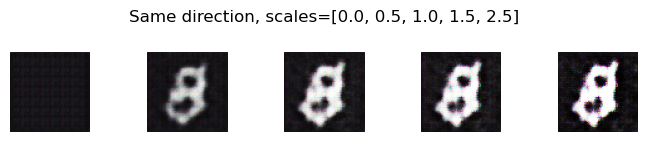

In [9]:
# 3. Scaling the noise vector's magnitude
base_z = make_noise(batch_size=1, seed=99)
scales = [0.0, 0.5, 1.0, 1.5, 2.5]
scaled_batch = torch.cat([base_z * s for s in scales], dim=0)

imgs = generate_images(scaled_batch)
show_images(imgs, ncols=5, title=f"Same direction, scales={scales}")